In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, GridSearchCV)
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       roc_curve, roc_auc_score, accuracy_score,
                                       precision_score, recall_score, f1_score,
                                       precision_recall_fscore_support)
 
print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [26]:
df = pd.read_csv('/Users/stevennn/cardiac-strainlabs/training models/Clinical-Dataset.csv')
 
print("DATA LOADED SUCCESSFULLY")
print(f"Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns : {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

DATA LOADED SUCCESSFULLY
Shape   : 5000 rows × 9 columns
Columns : ['Sl_no', 'Age', 'BMI', 'PROBNP', 'EF', 'GLS', 'NFATC3', 'DM', 'Risk_Level']

First 5 rows:
   Sl_no  Age  BMI  PROBNP  EF  GLS  NFATC3  DM Risk_Level
0      1   28   27     277  50  -20    0.89   0        Low
1      2   34   19    1149  43  -15    1.48   1   Moderate
2      3   22   19    1338  32  -18    1.14   0   Moderate
3      4   23   33    1547  52  -12    2.03   0   Moderate
4      5   67   22    1559  46  -28    1.30   0   Moderate


In [27]:
print("\n" + "=" * 60)
print("DATA EXPLORATION")
print("=" * 60)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())
print(f"\nDuplicate rows: {df.duplicated().sum()}")


DATA EXPLORATION

Data Types:
Sl_no           int64
Age             int64
BMI             int64
PROBNP          int64
EF              int64
GLS             int64
NFATC3        float64
DM              int64
Risk_Level     object
dtype: object

Missing Values:
Sl_no         0
Age           0
BMI           0
PROBNP        0
EF            0
GLS           0
NFATC3        0
DM            0
Risk_Level    0
dtype: int64

Basic Statistics:
             Sl_no          Age          BMI      PROBNP           EF  \
count  5000.000000  5000.000000  5000.000000  5000.00000  5000.000000   
mean   2500.500000    48.627800    26.029800   918.58800    49.348200   
std    1443.520003    18.148254     4.882508   506.37942    11.513499   
min       1.000000    18.000000    18.000000    50.00000    30.000000   
25%    1250.750000    33.000000    22.000000   486.00000    39.000000   
50%    2500.500000    48.000000    26.000000   921.00000    49.000000   
75%    3750.250000    65.000000    30.000000  1364.25

In [28]:
print("\n" + "=" * 60)
print("DM COLUMN VALIDATION")
print("=" * 60)
 
if 'DM' not in df.columns:
    raise ValueError(
        "❌  'DM' column not found!\n"
        "    Add DM (0 = No Diabetes, 1 = Diabetes) to your CSV and re-run."
    )
 
print(f"\n✓ DM column present")
print(f"  Unique values  : {sorted(df['DM'].dropna().unique())}")
print(f"  Missing values : {df['DM'].isna().sum()}")
print(f"  Distribution   :\n{df['DM'].value_counts().to_string()}")
 
if df['DM'].isna().sum() > 0:
    mode_val = int(df['DM'].mode()[0])
    df['DM'].fillna(mode_val, inplace=True)
    print(f"\n  ⚠ Missing DM values filled with mode = {mode_val}")
 
df['DM'] = df['DM'].astype(int)
 
invalid_dm = df[~df['DM'].isin([0, 1])]
if len(invalid_dm):
    raise ValueError(
        f"❌  DM contains values other than 0/1:\n{invalid_dm['DM'].value_counts()}"
    )
print("  ✓ DM validated — contains only 0 and 1")
 


DM COLUMN VALIDATION

✓ DM column present
  Unique values  : [0, 1]
  Missing values : 0
  Distribution   :
DM
0    2504
1    2496
  ✓ DM validated — contains only 0 and 1


In [29]:
print("\n" + "=" * 60)
print("FEATURES")
print("=" * 60)
 
target_col   = 'Risk_Level'
exclude_cols = [target_col, 'Sl_no']
 
feature_cols = [col for col in df.columns if col not in exclude_cols]
 
print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")
print(f"\n  Gender included : {'Gender' in feature_cols}")
print(f"  DM     included : {'DM' in feature_cols}")
 
X = df[feature_cols].copy()
 
nan_counts = X.isnull().sum()
if nan_counts.any():
    print(f"\n⚠ NaN values in features — filling with column median:")
    print(nan_counts[nan_counts > 0])
    X.fillna(X.median(), inplace=True)
    print("  ✓ NaNs filled")
else:
    print("\n  ✓ No missing values in features")


FEATURES

Features (7): ['Age', 'BMI', 'PROBNP', 'EF', 'GLS', 'NFATC3', 'DM']

  Gender included : False
  DM     included : True

  ✓ No missing values in features



FEATURE CORRELATION WITH TARGET

Correlations:
PROBNP    0.258527
DM        0.217678
Age       0.190573
BMI       0.116802
NFATC3    0.114623
GLS      -0.204562
EF       -0.268347


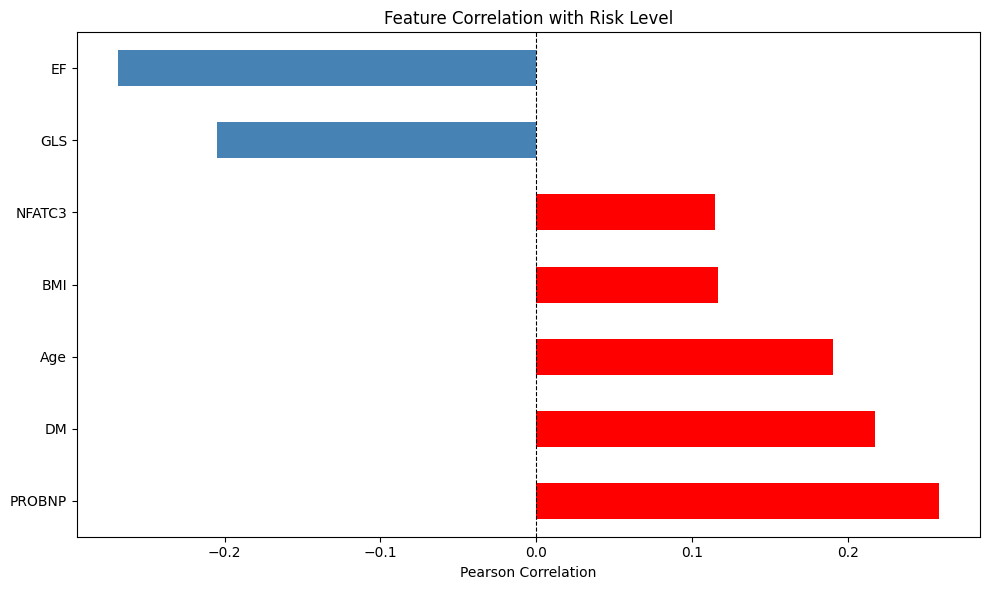

In [7]:
print("\n" + "=" * 60)
print("FEATURE CORRELATION WITH TARGET")
print("=" * 60)
 
correlations = X.corrwith(y).sort_values(ascending=False)
print("\nCorrelations:")
print(correlations.to_string())
 
plt.figure(figsize=(10, 6))
colors = ['red' if v > 0 else 'steelblue' for v in correlations]
correlations.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Feature Correlation with Risk Level')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('feature_correlations_v2.png', dpi=300, bbox_inches='tight')
plt.show()


TARGET VARIABLE ANALYSIS

Unique values in 'Risk_Level': ['High', 'Low', 'Moderate']

Mapping applied : {'Low': 0, 'Moderate': 1, 'High': 2}

Class Distribution:
Risk_Level
Low          425
Moderate    4112
High         463

Class Proportions (%):
Risk_Level
Low          8.50
Moderate    82.24
High         9.26

✓ All 3 classes confirmed: Low, Moderate, High


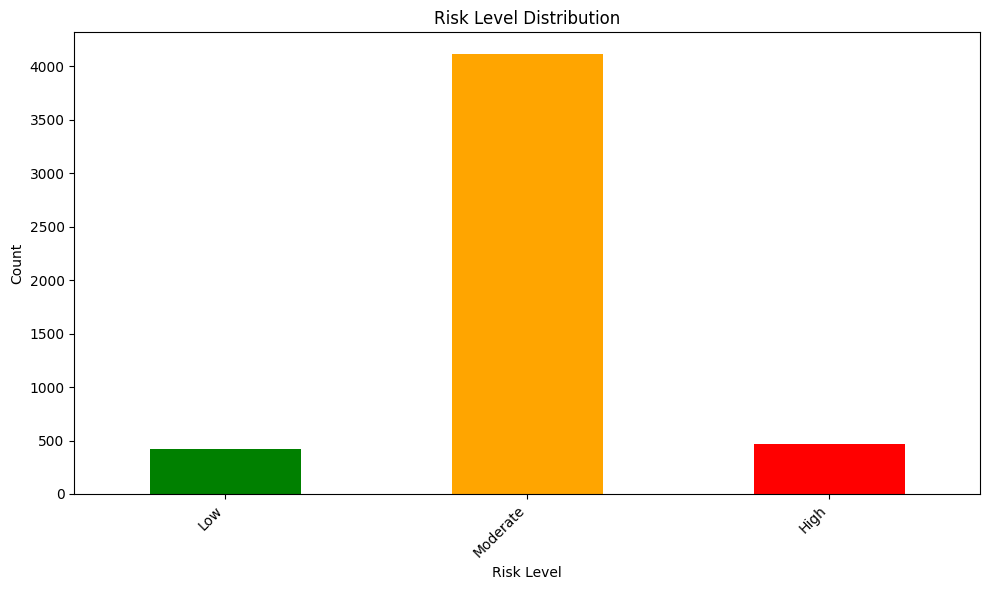


✓ Target variable defined


In [30]:
print("\n" + "=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)
 
# Strip whitespace from labels
y_raw = df[target_col].str.strip()
 
print(f"\nUnique values in '{target_col}': {sorted(y_raw.unique())}")
 
# CSV contains: 'Low', 'Moderate', 'High'
risk_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
class_names  = {0: 'Low', 1: 'Moderate', 2: 'High'}
 
y = y_raw.map(risk_mapping)
 
# Hard stop if anything didn't map
unmapped = y_raw[y.isna()].unique()
if len(unmapped):
    raise ValueError(
        f"❌  These values could not be mapped:\n"
        f"    Unmapped : {unmapped}\n"
        f"    Mapping  : {risk_mapping}"
    )
 
y = y.astype(int)
 
print(f"\nMapping applied : {risk_mapping}")
print(f"\nClass Distribution:")
print(y.value_counts().sort_index().rename(class_names).to_string())
print(f"\nClass Proportions (%):")
print((y.value_counts(normalize=True).sort_index().rename(class_names) * 100).round(2).to_string())
 
assert len(y.unique()) == 3, f"❌ Expected 3 classes, got: {sorted(y.unique())}"
print(f"\n✓ All 3 classes confirmed: Low, Moderate, High")
 
# Visualise
plt.figure(figsize=(10, 6))
y.value_counts().sort_index().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Moderate', 'High'], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Target variable defined")


FEATURE CORRELATION WITH TARGET

Correlations with Risk Level:
PROBNP    0.357697
DM        0.297164
Age       0.279648
BMI       0.185785
NFATC3    0.177627
GLS      -0.286272
EF       -0.353806


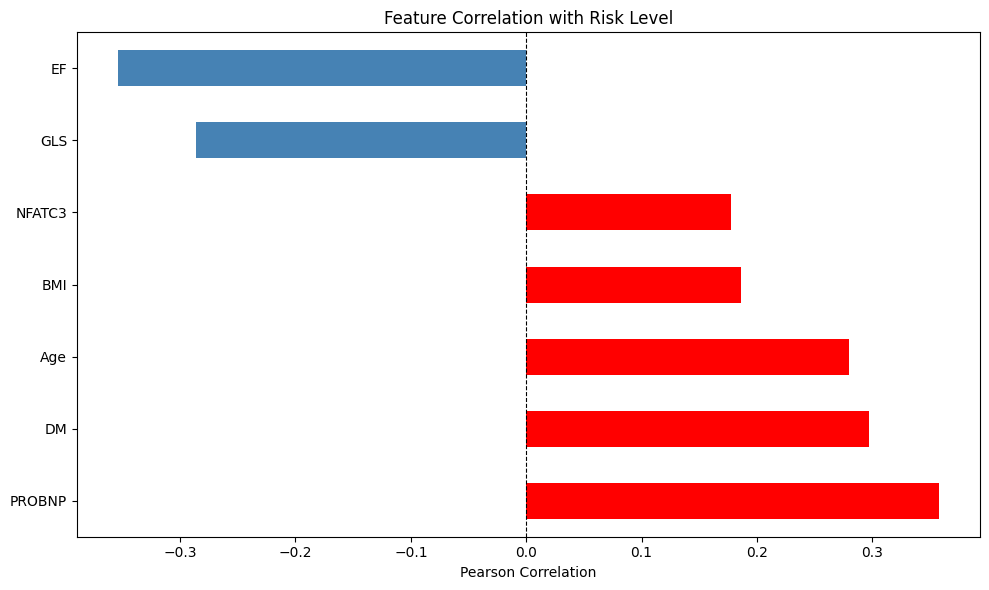

In [31]:
print("\n" + "=" * 60)
print("FEATURE CORRELATION WITH TARGET")
print("=" * 60)
 
correlations = X.corrwith(y).sort_values(ascending=False)
print("\nCorrelations with Risk Level:")
print(correlations.to_string())
 
plt.figure(figsize=(10, 6))
colors = ['red' if v > 0 else 'steelblue' for v in correlations]
correlations.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Feature Correlation with Risk Level')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT  (80 / 20, stratified)")
print("=" * 60)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"\nTraining set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class distribution:")
print(y_train.value_counts().sort_index().rename(class_names).to_string())
print(f"\nTest class distribution:")
print(y_test.value_counts().sort_index().rename(class_names).to_string())
print("\n✓ Data split complete")


TRAIN / TEST SPLIT  (80 / 20, stratified)

Training set : 4000 samples
Test set     : 1000 samples

Train class distribution:
Risk_Level
Low          340
Moderate    3290
High         370

Test class distribution:
Risk_Level
Low          85
Moderate    822
High         93

✓ Data split complete


In [33]:
print("\n" + "=" * 60)
print("FEATURE SCALING  (StandardScaler)")
print("=" * 60)
 
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
 
print(f"✓ Scaled — train: {X_train_scaled.shape}  |  test: {X_test_scaled.shape}")


FEATURE SCALING  (StandardScaler)
✓ Scaled — train: (4000, 7)  |  test: (1000, 7)


In [34]:
print("\n" + "=" * 60)
print("TRAINING MULTINOMIAL LOGISTIC REGRESSION")
print("=" * 60)
 
param_grid = {
    'C'      : [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50],
    'penalty': ['l2'],
    'solver' : ['lbfgs'],
}
 
lr_base = LogisticRegression(
    multi_class  = 'multinomial',   # softmax across all 3 classes
    class_weight = 'balanced',      # compensates for class imbalance
    max_iter     = 3000,
    random_state = 42
)
 
print("Running GridSearchCV (5-fold, scoring=f1_weighted) ...")
grid_search = GridSearchCV(lr_base, param_grid, cv=5,
                           scoring='f1_weighted', n_jobs=-1, verbose=0)
grid_search.fit(X_train_scaled, y_train)
 
model = grid_search.best_estimator_
print(f"\n✓ Best parameters : {grid_search.best_params_}")
print(f"✓ Best CV F1      : {grid_search.best_score_:.4f}")


TRAINING MULTINOMIAL LOGISTIC REGRESSION
Running GridSearchCV (5-fold, scoring=f1_weighted) ...

✓ Best parameters : {'C': 50, 'penalty': 'l2', 'solver': 'lbfgs'}
✓ Best CV F1      : 0.9875


In [35]:

NFATC3_THRESHOLD = 1.1
 
def apply_nfatc3_rule(preds: np.ndarray,
                      X_original: pd.DataFrame,
                      label: str = "") -> np.ndarray:
    """Force Low (0) if NFATC3 < threshold."""
    preds = preds.copy()
    if 'NFATC3' in X_original.columns:
        mask      = X_original['NFATC3'].values < NFATC3_THRESHOLD
        corrected = int(np.sum((preds != 0) & mask))
        preds[mask] = 0
        if corrected:
            print(f"  NFATC3 rule ({label}) → {corrected} prediction(s) corrected to Low")
    return preds

In [36]:
print("\n" + "=" * 60)
print("TRAINING SET PERFORMANCE")
print("=" * 60)
 
y_train_pred = apply_nfatc3_rule(
    model.predict(X_train_scaled), X_train, label="train"
)
 
train_accuracy  = accuracy_score (y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_recall    = recall_score   (y_train, y_train_pred, average='weighted', zero_division=0)
train_f1        = f1_score       (y_train, y_train_pred, average='weighted', zero_division=0)
 
print(f"\nAccuracy  : {train_accuracy :.4f}")
print(f"Precision : {train_precision:.4f}")
print(f"Recall    : {train_recall   :.4f}")
print(f"F1-Score  : {train_f1       :.4f}")
print("\nClassification Report (Training):")
print(classification_report(y_train, y_train_pred,
                            target_names=['Low', 'Moderate', 'High']))


TRAINING SET PERFORMANCE
  NFATC3 rule (train) → 742 prediction(s) corrected to Low

Accuracy  : 0.8045
Precision : 0.9363
Recall    : 0.8045
F1-Score  : 0.8431

Classification Report (Training):
              precision    recall  f1-score   support

         Low       0.31      1.00      0.47       340
    Moderate       1.00      0.78      0.87      3290
        High       0.95      0.88      0.91       370

    accuracy                           0.80      4000
   macro avg       0.75      0.88      0.75      4000
weighted avg       0.94      0.80      0.84      4000



In [37]:
print("\n" + "=" * 60)
print("CROSS-VALIDATION  (5-Fold Stratified)")
print("=" * 60)
 
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
cv_f1  = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
 
print(f"\nCV Accuracy : {cv_acc.mean():.4f}  (+/- {cv_acc.std()*2:.4f})")
print(f"  Folds     : {[f'{s:.4f}' for s in cv_acc]}")
print(f"\nCV F1       : {cv_f1.mean():.4f}  (+/- {cv_f1.std()*2:.4f})")
print(f"  Folds     : {[f'{s:.4f}' for s in cv_f1]}")


CROSS-VALIDATION  (5-Fold Stratified)

CV Accuracy : 0.9877  (+/- 0.0068)
  Folds     : ['0.9900', '0.9825', '0.9850', '0.9900', '0.9912']

CV F1       : 0.9879  (+/- 0.0066)
  Folds     : ['0.9901', '0.9828', '0.9853', '0.9901', '0.9913']


In [38]:
print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
 
y_test_pred = apply_nfatc3_rule(
    model.predict(X_test_scaled), X_test, label="test"
)
 
test_accuracy  = accuracy_score (y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall    = recall_score   (y_test, y_test_pred, average='weighted', zero_division=0)
test_f1        = f1_score       (y_test, y_test_pred, average='weighted', zero_division=0)
 
print(f"\nAccuracy  : {test_accuracy :.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall   :.4f}")
print(f"F1-Score  : {test_f1       :.4f}")
 
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_test_pred,
                            target_names=['Low', 'Moderate', 'High']))


TEST SET PERFORMANCE
  NFATC3 rule (test) → 172 prediction(s) corrected to Low

Accuracy  : 0.8170
Precision : 0.9361
Recall    : 0.8170
F1-Score  : 0.8516

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.32      1.00      0.49        85
    Moderate       1.00      0.79      0.88       822
        High       0.94      0.91      0.93        93

    accuracy                           0.82      1000
   macro avg       0.76      0.90      0.77      1000
weighted avg       0.94      0.82      0.85      1000




CONFUSION MATRIX
[[ 85   0   0]
 [170 647   5]
 [  7   1  85]]


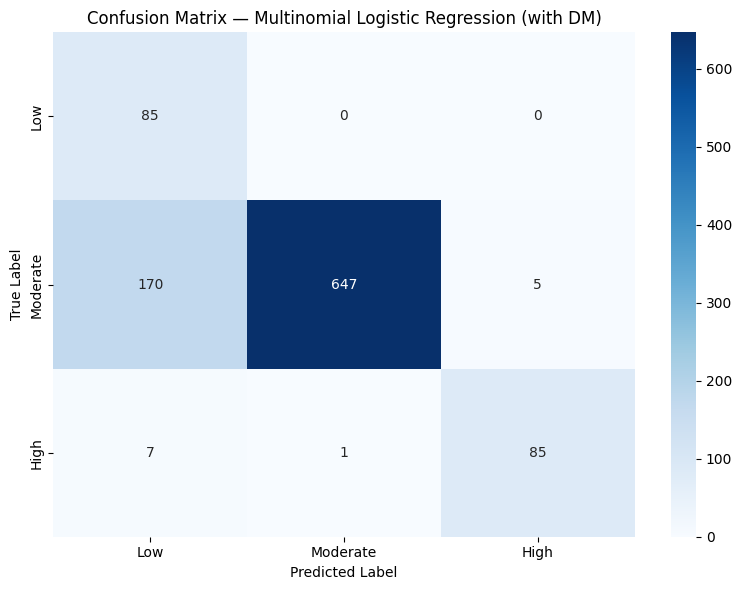

In [39]:
print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
 
cm = confusion_matrix(y_test, y_test_pred)
print(cm)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])
plt.title('Confusion Matrix — Multinomial Logistic Regression (with DM)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
print("\n" + "=" * 60)
print("PER-CLASS PERFORMANCE")
print("=" * 60)
 
prec_cls, rec_cls, f1_cls, sup_cls = \
    precision_recall_fscore_support(y_test, y_test_pred, average=None, zero_division=0)
 
for i, name in class_names.items():
    print(f"\n{name} ({i}):")
    print(f"  Precision : {prec_cls[i]:.4f}")
    print(f"  Recall    : {rec_cls[i] :.4f}")
    print(f"  F1-Score  : {f1_cls[i]  :.4f}")
    print(f"  Support   : {sup_cls[i]} samples")


PER-CLASS PERFORMANCE

Low (0):
  Precision : 0.3244
  Recall    : 1.0000
  F1-Score  : 0.4899
  Support   : 85 samples

Moderate (1):
  Precision : 0.9985
  Recall    : 0.7871
  F1-Score  : 0.8803
  Support   : 822 samples

High (2):
  Precision : 0.9444
  Recall    : 0.9140
  F1-Score  : 0.9290
  Support   : 93 samples



ROC-AUC


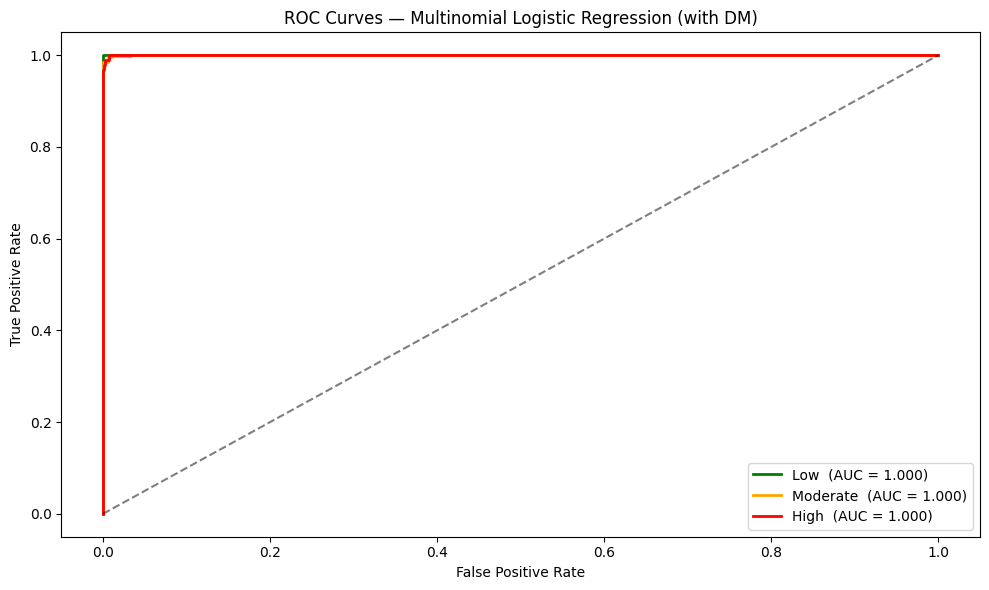


AUC Scores per Class:
  Low      : 1.0000
  Moderate : 0.9999
  High     : 0.9999

Macro-Average AUC : 0.9999


In [41]:
print("\n" + "=" * 60)
print("ROC-AUC")
print("=" * 60)
 
y_prob  = model.predict_proba(X_test_scaled)
roc_auc = {}
 
plt.figure(figsize=(10, 6))
colors_roc = ['green', 'orange', 'red']
for i in range(3):
    y_bin       = (y_test == i).astype(int)
    auc         = roc_auc_score(y_bin, y_prob[:, i])
    roc_auc[i]  = auc
    fpr, tpr, _ = roc_curve(y_bin, y_prob[:, i])
    plt.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
             label=f"{class_names[i]}  (AUC = {auc:.3f})")
 
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Multinomial Logistic Regression (with DM)')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
 
macro_auc = np.mean(list(roc_auc.values()))
print(f"\nAUC Scores per Class:")
for i, auc in roc_auc.items():
    print(f"  {class_names[i]:8s} : {auc:.4f}")
print(f"\nMacro-Average AUC : {macro_auc:.4f}")


FEATURE IMPORTANCE  (Logistic Regression Coefficients)

Feature Coefficients (per class):
              Low  Moderate       High
EF      18.392371  0.176112 -18.568483
PROBNP -18.050937 -0.238838  18.289776
DM     -15.895591 -0.285524  16.181115
GLS     14.253060  0.123286 -14.376346
Age    -14.049929 -0.206656  14.256585
BMI     -9.635051 -0.298040   9.933091
NFATC3  -9.038551 -0.104994   9.143545


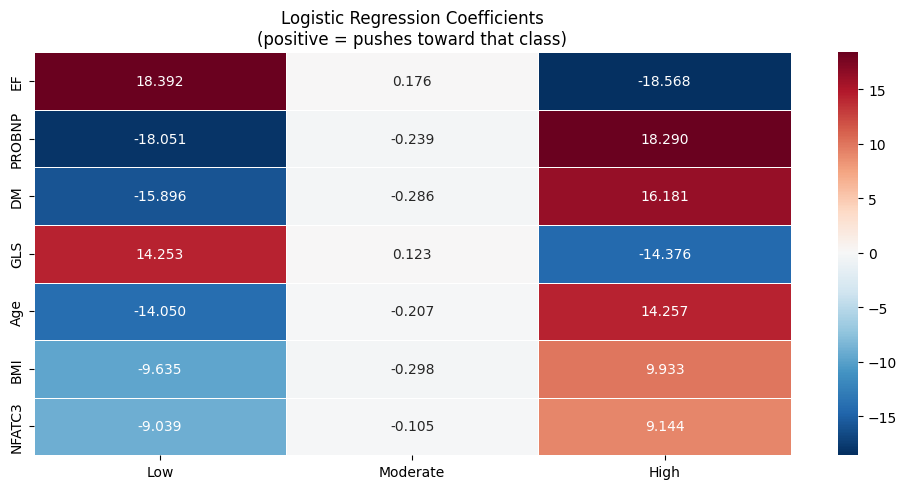

In [42]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE  (Logistic Regression Coefficients)")
print("=" * 60)
 
# model.coef_ → shape (3, n_features) for multinomial
coef_df = pd.DataFrame(
    model.coef_,
    index  = ['Low', 'Moderate', 'High'],
    columns= feature_cols
).T
 
coef_df['Abs_Max'] = coef_df.abs().max(axis=1)
coef_df = coef_df.sort_values('Abs_Max', ascending=False)
 
print("\nFeature Coefficients (per class):")
print(coef_df.drop(columns='Abs_Max').to_string())
 
# Coefficient heatmap
plt.figure(figsize=(10, max(5, len(feature_cols) * 0.6)))
sns.heatmap(coef_df.drop(columns='Abs_Max'),
            annot=True, fmt='.3f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Logistic Regression Coefficients\n(positive = pushes toward that class)')
plt.tight_layout()
plt.savefig('feature_importance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

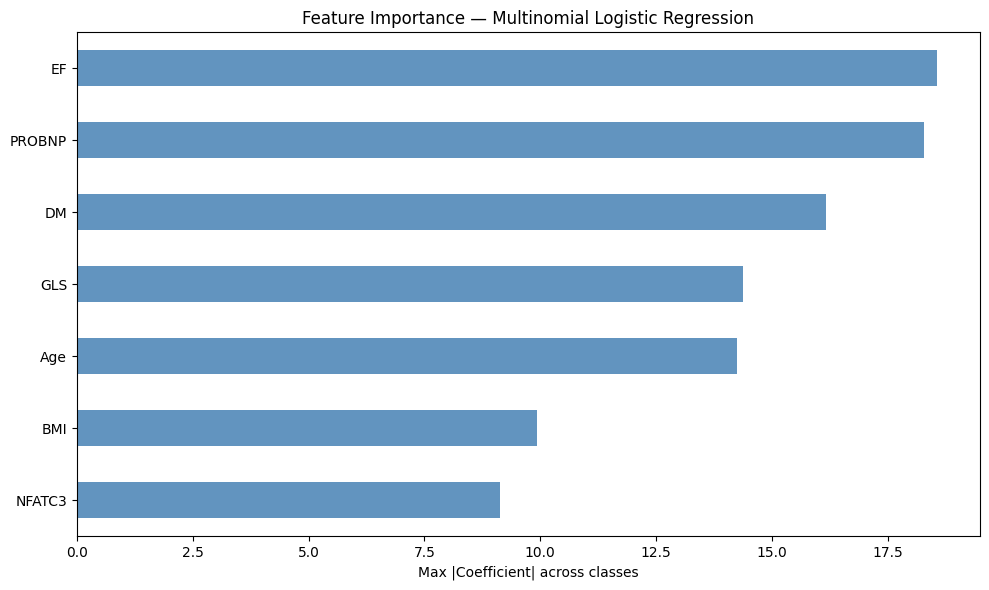


Feature ranking (most → least important):
              Low  Moderate       High    Abs_Max
EF      18.392371  0.176112 -18.568483  18.568483
PROBNP -18.050937 -0.238838  18.289776  18.289776
DM     -15.895591 -0.285524  16.181115  16.181115
GLS     14.253060  0.123286 -14.376346  14.376346
Age    -14.049929 -0.206656  14.256585  14.256585
BMI     -9.635051 -0.298040   9.933091   9.933091
NFATC3  -9.038551 -0.104994   9.143545   9.143545


In [43]:
plt.figure(figsize=(10, 6))
coef_df['Abs_Max'].sort_values().plot(kind='barh', color='steelblue', alpha=0.85)
plt.xlabel('Max |Coefficient| across classes')
plt.title('Feature Importance — Multinomial Logistic Regression')
plt.tight_layout()
plt.savefig('feature_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()
 
print("\nFeature ranking (most → least important):")
print(coef_df[['Low', 'Moderate', 'High', 'Abs_Max']].to_string())

In [44]:
print("\n" + "=" * 60)
print("PREDICTION FOR NEW PATIENT")
print("=" * 60)
 
new_patient = {
    'Age'   : 28,
    'Gender': 1,
    'BMI'   : 28,
    'DM'    : 0,       # 0 = No Diabetes  |  1 = Diabetes
    'PROBNP': 420,
    'EF'    : 48,
    'GLS'   : -10,
    'NFATC3': 1.45,
}
 
# Align to training column order
new_patient_df     = pd.DataFrame([new_patient])[feature_cols]
new_patient_scaled = scaler.transform(new_patient_df)
 
raw_pred    = model.predict(new_patient_scaled)[0]
probability = model.predict_proba(new_patient_scaled)[0]
 
# Apply NFATC3 rule
if new_patient.get('NFATC3', 999) < NFATC3_THRESHOLD:
    raw_pred = 0
    print(f"  ⚠ NFATC3 rule applied → prediction forced to Low")
 
risk_desc = {
    0: 'Low Risk     — Normal cardiac function',
    1: 'Moderate Risk — Requires monitoring',
    2: 'High Risk     — Immediate attention recommended',
}
 
print("\nPatient Information:")
for k, v in new_patient.items():
    note = ""
    if k == 'DM':
        note = "  (No Diabetes)" if v == 0 else "  (Diabetes)"
    print(f"  {k:12s}: {v}{note}")
 
print(f"\n{'='*55}")
print(f"  PREDICTION : {class_names[raw_pred]}")
print(f"  ASSESSMENT : {risk_desc[raw_pred]}")
print(f"{'='*55}")
 
print(f"\nClass Probabilities:")
bar_len = 45
for i, nm in class_names.items():
    blocks = '█' * int(probability[i] * bar_len)
    print(f"  {nm:8s}: {blocks:<{bar_len}} {probability[i]:6.1%}")
print(f"\nModel Confidence : {max(probability):.1%}")


PREDICTION FOR NEW PATIENT

Patient Information:
  Age         : 28
  Gender      : 1
  BMI         : 28
  DM          : 0  (No Diabetes)
  PROBNP      : 420
  EF          : 48
  GLS         : -10
  NFATC3      : 1.45

  PREDICTION : Low
  ASSESSMENT : Low Risk     — Normal cardiac function

Class Probabilities:
  Low     : ████████████████████████████████████████████  100.0%
  Moderate:                                                 0.0%
  High    :                                                 0.0%

Model Confidence : 100.0%


In [45]:
import joblib

# Save the model
joblib.dump(model, 'heart_lr_dm.pkl')

# Save the scaler (IMPORTANT — needed for predictions)
joblib.dump(scaler, 'scaler_lr_dm.pkl')

# Save feature columns (IMPORTANT — ensures correct column order)
joblib.dump(feature_cols, 'feature_cols_lr_dm.pkl')

print("✓ Model saved as 'heart_lr_dm.pkl'")
print("✓ Scaler saved as 'scaler_lr_dm.pkl'")
print("✓ Feature columns saved as 'feature_cols_lr_dm.pkl'")

# Verify by reloading
loaded_model    = joblib.load('heart_lr_dm.pkl')
loaded_scaler   = joblib.load('scaler_lr_dm.pkl')
loaded_features = joblib.load('feature_cols_lr_dm.pkl')

print("\n✓ All files reloaded successfully")
print(f"  Model type     : {type(loaded_model)}")
print(f"  Feature cols   : {loaded_features}")

✓ Model saved as 'heart_lr_dm.pkl'
✓ Scaler saved as 'scaler_lr_dm.pkl'
✓ Feature columns saved as 'feature_cols_lr_dm.pkl'

✓ All files reloaded successfully
  Model type     : <class 'sklearn.linear_model._logistic.LogisticRegression'>
  Feature cols   : ['Age', 'BMI', 'PROBNP', 'EF', 'GLS', 'NFATC3', 'DM']


In [46]:
print("\n" + "=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
print(f"""
  Model         : Multinomial Logistic Regression (softmax)
  Classes       : Low (0) | Moderate (1) | High (2)
  Features ({len(feature_cols):2d}) : {feature_cols}
  DM included   : ✓
  Best C        : {grid_search.best_params_['C']}
  Class weight  : balanced
 
  Training Performance:
    Accuracy  : {train_accuracy :.4f}
    Precision : {train_precision:.4f}
    Recall    : {train_recall   :.4f}
    F1-Score  : {train_f1       :.4f}
 
  Test Performance:
    Accuracy  : {test_accuracy :.4f}
    Precision : {test_precision:.4f}
    Recall    : {test_recall   :.4f}
    F1-Score  : {test_f1       :.4f}
 
  Cross-Validation (5-fold):
    CV Accuracy : {cv_acc.mean():.4f}  (+/- {cv_acc.std()*2:.4f})
    CV F1       : {cv_f1.mean():.4f}  (+/- {cv_f1.std()*2:.4f})
 
  Macro ROC-AUC : {macro_auc:.4f}
 
  Saved Files:
    heart_lr_dm.pkl
    scaler_lr_dm.pkl
    feature_cols_lr_dm.pkl
    risk_mapping_lr_dm.pkl
""")


MODEL SUMMARY

  Model         : Multinomial Logistic Regression (softmax)
  Classes       : Low (0) | Moderate (1) | High (2)
  Features ( 7) : ['Age', 'BMI', 'PROBNP', 'EF', 'GLS', 'NFATC3', 'DM']
  DM included   : ✓
  Best C        : 50
  Class weight  : balanced
 
  Training Performance:
    Accuracy  : 0.8045
    Precision : 0.9363
    Recall    : 0.8045
    F1-Score  : 0.8431
 
  Test Performance:
    Accuracy  : 0.8170
    Precision : 0.9361
    Recall    : 0.8170
    F1-Score  : 0.8516
 
  Cross-Validation (5-fold):
    CV Accuracy : 0.9877  (+/- 0.0068)
    CV F1       : 0.9879  (+/- 0.0066)
 
  Macro ROC-AUC : 0.9999
 
  Saved Files:
    heart_lr_dm.pkl
    scaler_lr_dm.pkl
    feature_cols_lr_dm.pkl
    risk_mapping_lr_dm.pkl

